### **Figure 3: _Loss of keratin expression diminishes EVL epiboly movements_ Notebook**

This notebook provides tools and data to recreate the figure 3 from Naik et al 2026. 
It has been modified code from the original [repo](https://github.com/Suyash-Naik/PaperPythonScripting) to allow for all orginal source data retrival from the repository and plotting using standarized versions of the code to plot the figures. 

**Author**: Suyash Naik

In [1]:
#Import block
from src.BinnedPlotter import BinnedIntensityPlotter

from src.Figureplot import setup_figure, intensity_data_sorting,build_nd_raw_dataset,plot_nd_surface
import os
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import re 

Figureplot.py run on  20260224


### **Figure 3B**: _Keratin network density in knockdowns and mutants_

Plot of averaged density of keratin network in individual EVL cells as a function of time (hpf) during epiboly in Tg(actb2:Utrophinmcherry, krt18:Krt18GFP) embryos injected at the one-cell stage with 2 ng control MO (top row; green, N = 4, n = 4 embryos), 1 ng keratin 4 plus 1 ng keratin 8 MO (middle row; blue, N = 4, n = 4 embryos), or with TraCr keratin 4 and keratin 8 gRNA (keratin 4/8 crispant F0; bottom row; pink, N = 2, n = 6 embryos). 

Error bars as ribbon SD of the mean of individual cells per replicate.

In [ ]:
networkdata=pd.read_csv('data/Fig3/3B/NetworkDensity.csv')


In [ ]:
speeddatafolder= glob("data/Fig3/3D/*xlsx")
pd1=pd.read_excel(speeddatafolder[0],sheet_name="Sheet1")
pd2=pd.read_excel(speeddatafolder[1],sheet_name="Sheet1")
pd3=pd.read_excel(speeddatafolder[2],sheet_name="Sheet1")

IndexError: list index out of range

In [12]:
pd2

,Time (hpf),vPos001,vPos002,vPos003,vPos004,vPos005,Time
0,0.000000,1.903929,2.593643,0.553357,0.038286,0.246786,4.000000
1,0.233333,0.682643,0.832714,0.625357,0.219857,0.143500,4.233333
2,0.466667,1.036786,1.255929,0.849071,1.241214,1.019929,4.466667
3,0.700000,1.740714,1.251857,0.519571,1.433286,0.790214,4.700000
4,0.933333,1.900500,1.005071,1.453786,1.340786,0.982786,4.933333
5,1.166667,1.317500,1.832500,1.191071,2.792071,0.957143,5.166667
6,1.400000,0.220286,0.963571,0.916929,1.659786,0.567929,5.400000
7,1.633333,2.285714,1.057929,1.381643,2.289071,1.092286,5.633333
8,1.866667,1.699500,1.154786,1.044357,1.473857,1.078714,5.866667
9,2.100000,1.418500,1.424214,1.333000,1.954357,1.019714,6.100000


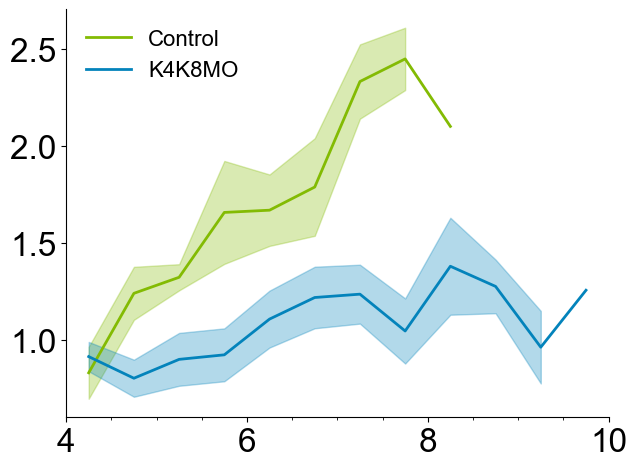

In [7]:
bin_edges = np.arange(4, 10.7, 0.5)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

binnedEpiSpeedData = pd.DataFrame({"Time (hpf)": bin_centers})

def add_binned(df, time_col, cols, out_prefix):
    for col in cols:
        vals = np.array([
            df.loc[(df[time_col] >= bin_edges[i]) & (df[time_col] < bin_edges[i+1]), col].mean()
            for i in range(len(bin_centers))
        ])
        binnedEpiSpeedData[f"{out_prefix}{col}"] = vals

controlcolumns21303 = ["vPos001", "vPos002"]
controlcolumns19012023 = ["1901vPos001", "1901vPos002"]
k4k8mocols21303 = ["vPos003", "vPos004"]
k4k8mocols19012023 = ["1901vPos003", "1901vPos004"]

add_binned(pd1, "Time", controlcolumns21303, "control_210323_")
add_binned(pd2, "Time (hpf)", controlcolumns19012023, "control_")
add_binned(pd1, "Time", k4k8mocols21303, "K4K8MO_210323_")
add_binned(pd2, "Time (hpf)", k4k8mocols19012023, "K4K8MO_")
os.makedirs("Figure/Figure3/3D/", exist_ok=True)
plotter = BinnedIntensityPlotter(
    intensity_files=[],
    bin_edges=bin_edges,
    save_folder="Figure/Figure3/3D/"
)

plotter.import_data(binnedEpiSpeedData)
plotter.plot_data(
    colors={"control": "#83bb03", "K4K8MO": "#0383bb"},
    labels={"control": "Control", "K4K8MO": "K4K8MO"}
)